In [1]:
from dataset import DartsDataset
import os
import json
from torch.utils.data import random_split
import torch
from PIL import Image, ImageDraw
import random
%load_ext autoreload
%autoreload 2

In [2]:
dirs = [f'3D/scene/rendered_dual_corners/imgs_{i}' for i in range(5)]
dataset = DartsDataset(dirs=dirs, random_rotation=False, random_rescale=False)
train_size = int(0.8 * len(dataset))
val_size = (len(dataset) - train_size) // 2
test_size = len(dataset) - train_size - val_size
train_dataset, validation_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))
# test_dataset = DartsDataset(dirs=[f'my_unlabelled/vids/frames_000{i}' for i in range(8)], random_rescale=False, random_rotation=False, is_synthetic=False)

In [3]:
categories = [
    {
        "id": 1,
        "name": "right",
        "supercategory": "darts",
    },
    {
        "id": 2,
        "name": "top",
        "supercategory": "darts",
    },
    {
        "id": 3,
        "name": "left",
        "supercategory": "darts",
    },
    {
        "id": 4,
        "name": "bottom",
        "supercategory": "darts",
    },
    {
        "id": 5,
        "name": "dart",
        "supercategory": "darts",
    }
]

In [4]:
path, img, anno1, img_transformed, anno2 = train_dataset[random.randint(0, len(train_dataset)-1)]

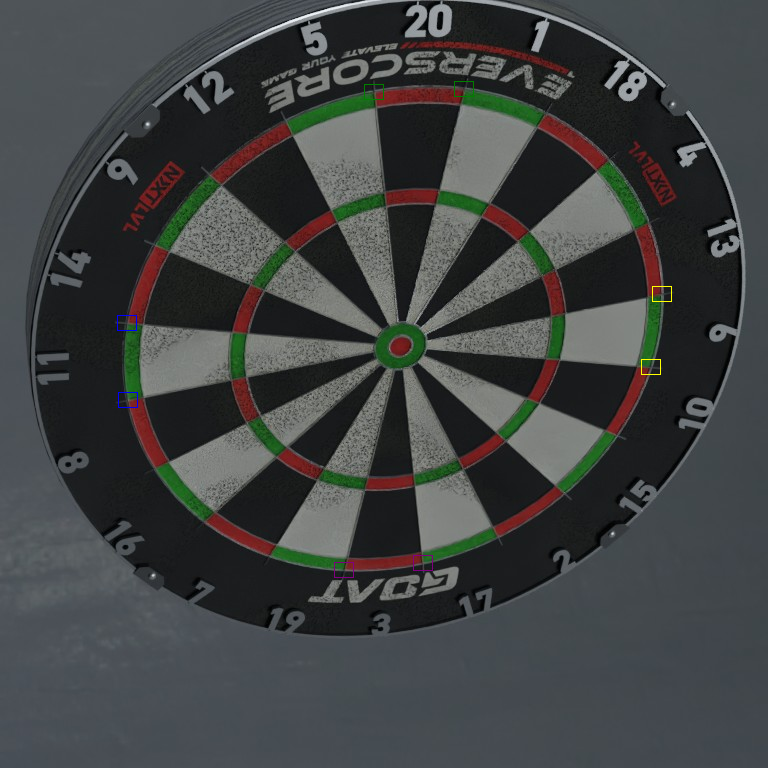

In [5]:
def drawbbox(draw, box, color):
    x,y,w,h = box
    x0, y0, x1, y1 = x, y, x+w, y+h
    draw.rectangle([x0, y0, x1, y1], outline=color)
draw = ImageDraw.Draw(img)
for anno in anno1["annotations"]:
    color = random.choice(['red', 'blue', 'green', 'yellow', 'purple'])
    box1, box2 = anno["bbox"].split(4, dim=-1)
    drawbbox(draw, box1, color) 
    drawbbox(draw, box2, color) 
img

In [6]:
def make_coco_dataset(dataset, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    images = []
    annotations = []
    anno_id = 0
    for idx, (path, img, anno1, img_transformed, anno2) in enumerate(dataset):
        filename = os.path.basename(path)

        img.save(f"{output_dir}/{filename}")
        img_transformed.save(f"{output_dir}/transformed_{filename}")
        images.append({
            "id": 2*idx,
            "width": img.width,
            "height": img.height,
            "file_name": filename,
            "date_captured": "",
        })
        images.append({
            "id": 2*idx+1,
            "width": img_transformed.width,
            "height": img_transformed.height,
            "file_name": f"transformed_{filename}",
            "date_captured": "",
        })
        
        for anno in anno1["annotations"]:
            anno["id"] = anno_id
            anno["image_id"] = 2*idx
            anno["bbox"] = list(map(float, anno["bbox"].numpy()))
            anno["category_id"] = int(anno["category_id"])
            anno["area"] = float(anno["area"])
            anno["iscrowd"] = 0
            anno_id += 1
            annotations.append(anno)


        for anno in anno2["annotations"]:
            anno["id"] = anno_id
            anno["image_id"] = 2*idx+1
            anno["bbox"] = list(map(float, anno["bbox"].numpy()))
            anno["category_id"] = int(anno["category_id"])
            anno["area"] = float(anno["area"])
            anno["iscrowd"] = 0
            anno_id += 1
            annotations.append(anno)

    dataset_dict = {
        "info": {
            "description": "Darts Dataset"
        },
        "images": images,
        "annotations": annotations,
        "categories": categories,
    }

    with open(f"{output_dir}/_annotations.coco.json", "w") as f:
        json.dump(dataset_dict, f)

In [7]:
make_coco_dataset(train_dataset, "dataset_dual_corners/train")
make_coco_dataset(validation_dataset, "dataset_dual_corners/valid")
make_coco_dataset(test_dataset, "dataset_dual_corners/test")